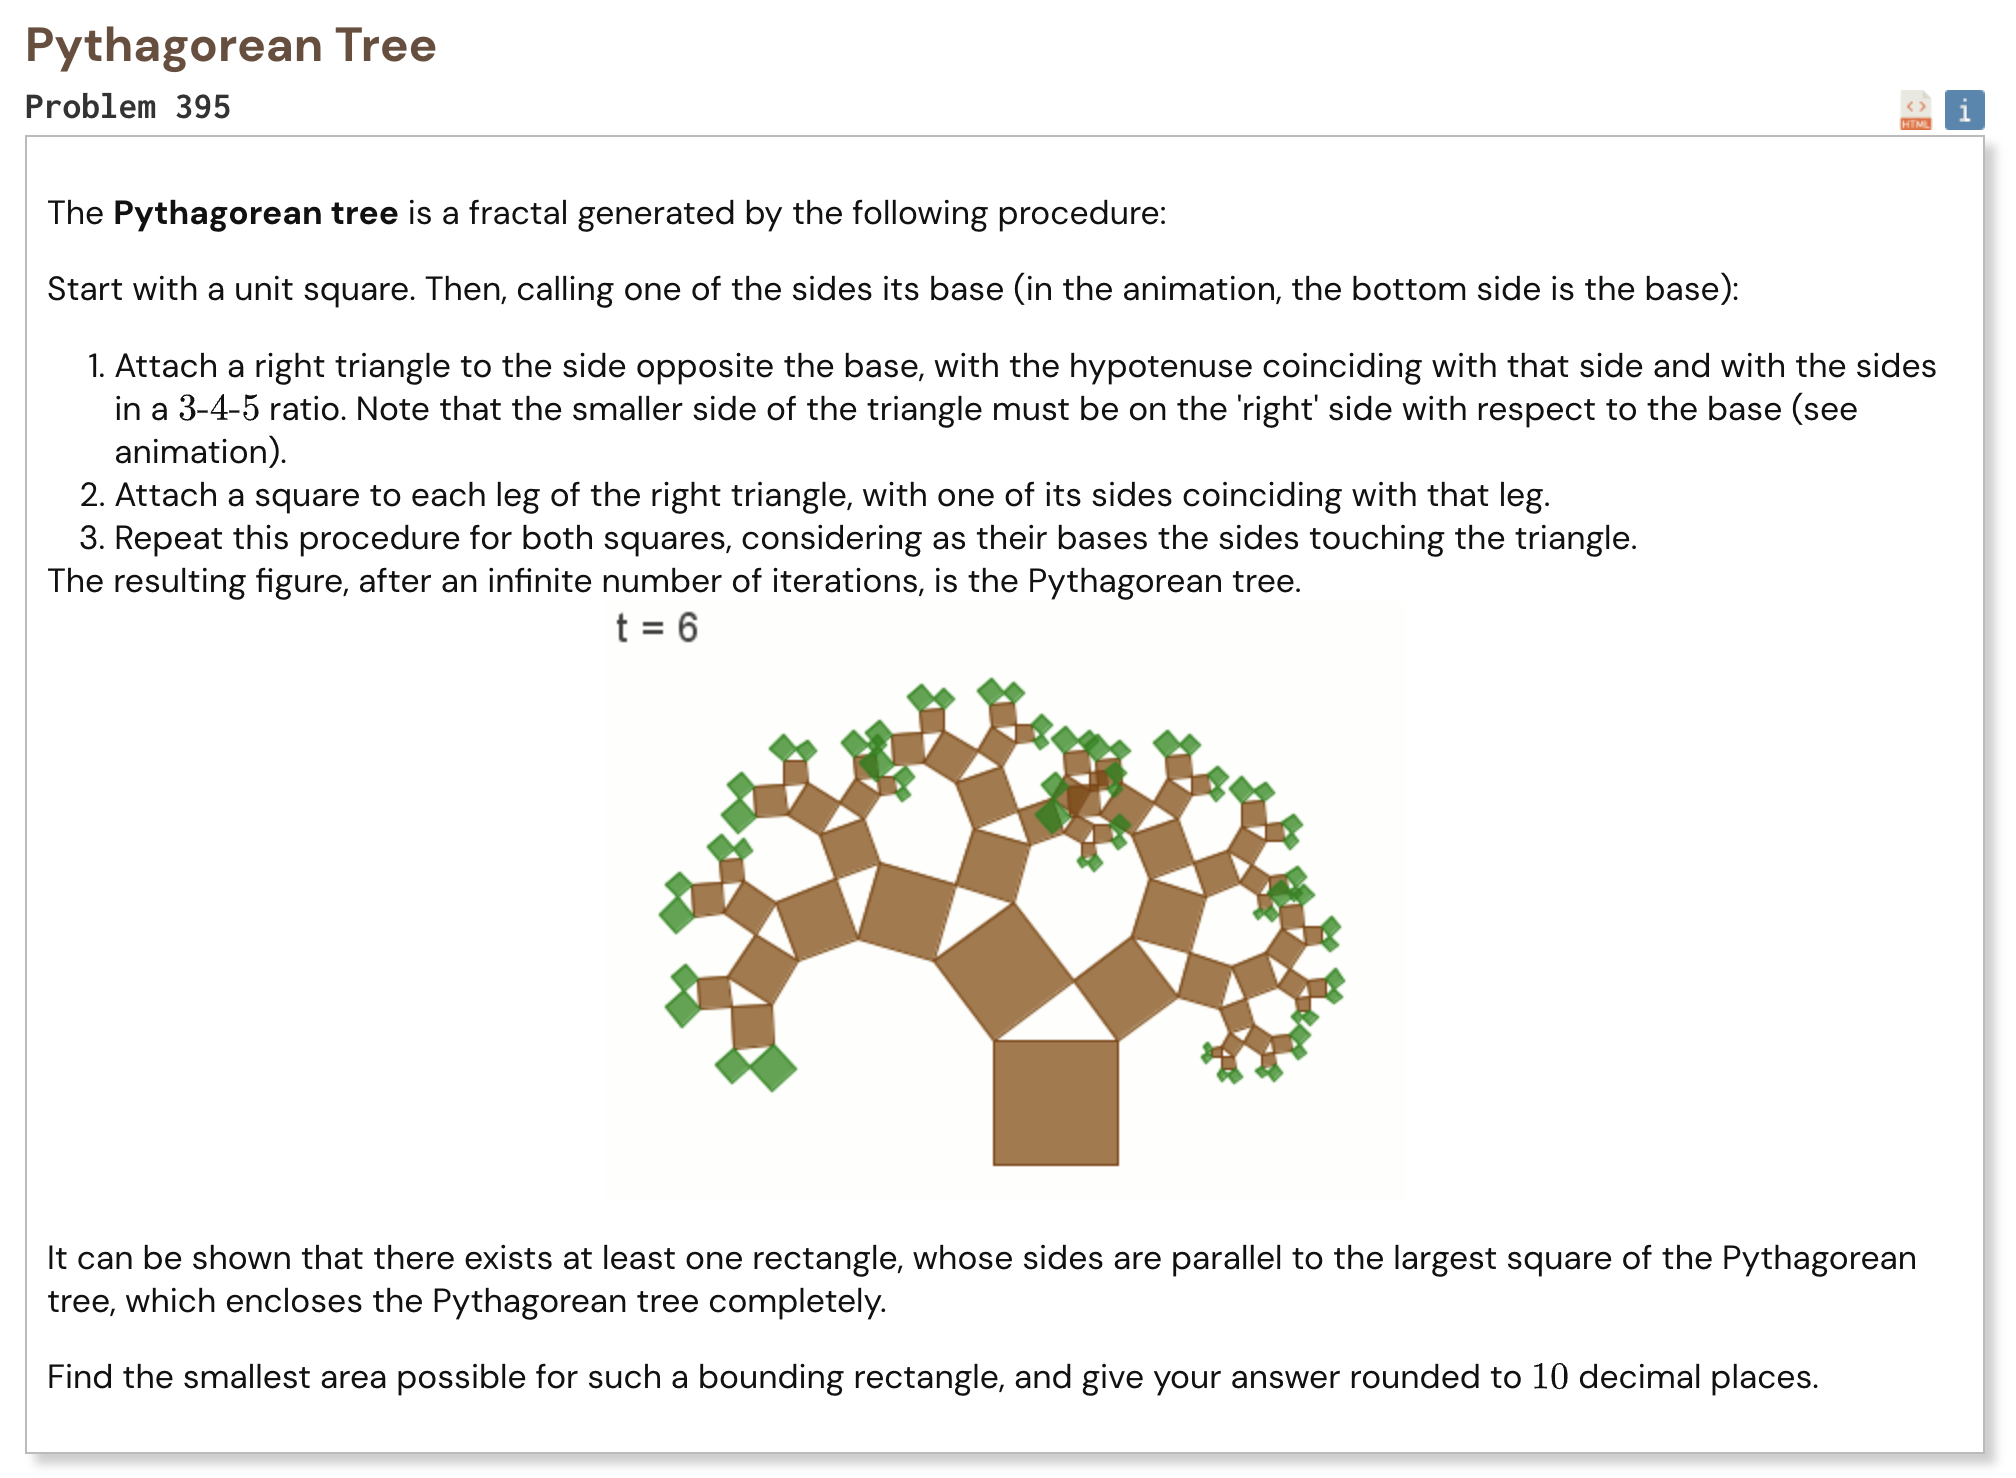

## Initial approach

-   represent every square using its starting corner and one base vector
-   the two child squares are rotated and scaled copies with side lengths four fifths and three fifths
-   use a support function to find the farthest point in one chosen direction
-   calculate the four extreme values for left right top and bottom separately
-   store possible subtrees in a priority queue and always examine the most promising one first
-   use a safe radius bound to skip any subtree that cannot improve the current extreme
-   combine the four extreme coordinates to get the width and height
-   multiply them and round the final area to ten decimal places

In [1]:
import heapq
import math


def dot(first, second):
    return first[0] * second[0] + first[1] * second[1]


def transpose_multiply(multiplier, direction):
    real, imaginary = multiplier
    x, y = direction

    return (
        real * x + imaginary * y,
        -imaginary * x + real * y
    )


def square_support(direction):
    x, y = direction
    return max(0.0, x, y, x + y)


def tree_support(direction):
    left_multiplier = (16 / 25, 12 / 25)
    right_multiplier = (9 / 25, -12 / 25)

    left_translation = (0.0, 1.0)
    right_translation = (16 / 25, 37 / 25)

    radius_bound = 5.0
    tolerance = 1e-14

    best = square_support(direction)
    initial_upper = radius_bound * math.hypot(*direction)

    heap = [
        (-initial_upper, 0.0, direction)
    ]

    while heap:
        negative_upper, offset, current_direction = heapq.heappop(heap)
        upper = -negative_upper

        if upper <= best + tolerance:
            break

        lower = offset + square_support(current_direction)
        best = max(best, lower)

        children = [
            (left_multiplier, left_translation),
            (right_multiplier, right_translation)
        ]

        for multiplier, translation in children:
            next_direction = transpose_multiply(
                multiplier,
                current_direction
            )

            next_offset = (
                offset
                + dot(current_direction, translation)
            )

            next_lower = (
                next_offset
                + square_support(next_direction)
            )

            best = max(best, next_lower)

            next_upper = (
                next_offset
                + radius_bound * math.hypot(*next_direction)
            )

            if next_upper > best + tolerance:
                heapq.heappush(
                    heap,
                    (-next_upper, next_offset, next_direction)
                )

    return best

In [2]:
%%time
right = tree_support((1.0, 0.0))
left = tree_support((-1.0, 0.0))
top = tree_support((0.0, 1.0))
bottom = tree_support((0.0, -1.0))
width = right + left
height = top + bottom
result = width * height
print("Result:", f"{result:.10f}")

Result: 28.2453753155
CPU times: user 4.48 ms, sys: 124 μs, total: 4.6 ms
Wall time: 4.66 ms
